Class Distribution:
   X65  Proportion
0    0    0.808243
1    1    0.191757


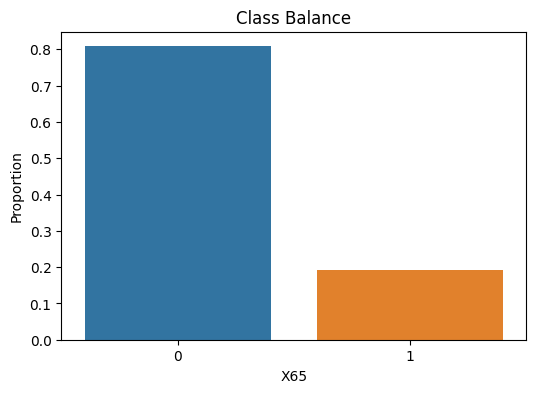


Features with >15% Missing Values:
   Feature  Missing %
20     X21  25.410409
36     X37  41.957737

Top 10 Right-Skewed Features:
X58    106.896645
X20    106.871232
X43    106.321921
X44    105.903131
X23     94.411969
X31     93.917277
X19     93.915049
X62     93.517843
X50     93.412342
X40     92.740512
dtype: float64

Top 10 Left-Skewed Features:
X1     -59.090734
X3     -59.379837
X5     -66.618034
X39    -68.263276
X12    -71.875315
X45    -72.632611
X26    -74.424438
X16    -74.809915
X49   -101.572223
X56   -106.858715
dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score


df = pd.read_csv('/kaggle/input/combine-bankruptcy-data/combined_data.csv', na_values=['?', ' ', 'NA'])  # Replace with your path
target_col = 'X65' 
df.drop('X66', axis=1, inplace=True)
for col in df.columns:
    if col != target_col: 
        df[col] = pd.to_numeric(df[col], errors='coerce') 

# 1. Class imbalance
class_dist = df[target_col].value_counts(normalize=True).reset_index()
class_dist.columns = [target_col, 'Proportion']
print("Class Distribution:")
print(class_dist)
plt.figure(figsize=(6, 4))
sns.barplot(x=target_col, y='Proportion', data=class_dist)
plt.title('Class Balance')
plt.show()

# 2. Missing values
missing = df.isnull().sum().reset_index()
missing.columns = ['Feature', 'Missing Count']
missing['Missing %'] = (missing['Missing Count'] / len(df)) * 100
high_missing = missing[missing['Missing %'] > 15]
print("\nFeatures with >15% Missing Values:")
print(high_missing[['Feature', 'Missing %']])

# 3. Distributions (skewness)
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
numeric_features = [f for f in numeric_features if f != target_col]

skewness = df[numeric_features].skew().sort_values(ascending=False)
print("\nTop 10 Right-Skewed Features:")
print(skewness.head(10))
print("\nTop 10 Left-Skewed Features:")
print(skewness.tail(10))



FE

In [2]:
import pandas as pd
import numpy as np


df = pd.read_csv('/kaggle/input/combine-bankruptcy-data/combined_data.csv')
target_col = 'X65'
for col in df.columns:
    if col != target_col:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop X37 (42% missing)
df = df.drop(columns=['X37'])

# Impute X21 (Sales Growth) + flag missingness
df['sales_growth_imputed'] = df['X21'].fillna(df['X21'].median())
df['sales_growth_missing_flag'] = df['X21'].isnull().astype(int)

# Winsorize right-skewed features (cap at 95th percentile)
right_skewed = ['X20', 'X43', 'X58', 'X44']
for col in right_skewed:
    upper = np.percentile(df[col].dropna(), 95)
    df[f'{col}_winsorized'] = np.clip(df[col], None, upper)

# Transform left-skewed features
df['gross_margin_inv'] = 1 / (df['X56'] + 1e-6)  # Avoid division by zero

# --- Composite Scores ---
# Altman Z-Score (using original coefficients)
df['altman_z_score'] = (
    1.2 * (df['X3'] / df['X17']) +  # Working Capital/TA (X3 = WC/TA)
    1.4 * df['X6'] +                  # Retained Earnings/TA
    3.3 * df['X7'] +                  # EBIT/TA
    0.6 * df['X8'] +                  # Equity/Liabilities
    1.0 * df['X9']                    # Sales/TA
)

# Liquidity Stress Score
df['liquidity_stress_score'] = (df['X3'] + df['X5'] + df['X12']) / 3

# --- Interaction Terms ---
df['inventory_leverage_risk'] = df['X20_winsorized'] * df['X2']
df['margin_cost_squeeze'] = df['X56'] * df['X58_winsorized']

# --- Binary Flags ---
df['liquidity_crisis_flag'] = (df['X4'] < 1).astype(int)
df['negative_equity_flag'] = (df['X10'] < 0).astype(int)
df['interest_coverage_risk'] = (df['X27'] < 1).astype(int)

df = df.drop(columns=right_skewed + ['X56', 'X21'])
df.to_csv('bankruptcy_data_engineered.csv', index=False)

/tmp/ipykernel_14/415536494.py:5: DtypeWarning: Columns (0,1,2,5,6,9,10,13,17,21,24,28,34,35,37,47,50) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/kaggle/input/combine-bankruptcy-data/combined_data.csv')
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value enco